In [1]:
# importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')


In [ ]:
# loading data

df = pd.read_csv("../data/raw/insurance-charges.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# checking shape of the dataframe

df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# checking null values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
# checking duplicates

df.duplicated().sum()

np.int64(1)

In [24]:
# removing the duplicates

df.drop_duplicates(inplace = True)
# inplace = True modifies the original dataframe instead of creating and returning a modified copy

df.shape

(1337, 7)

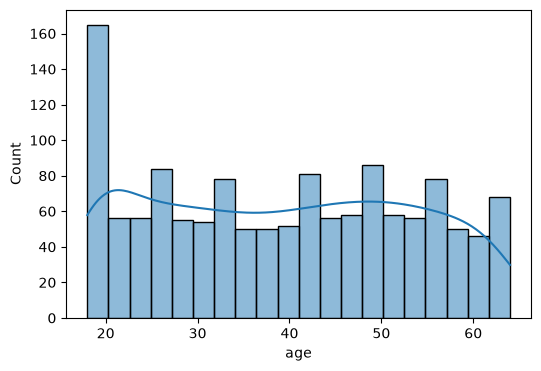

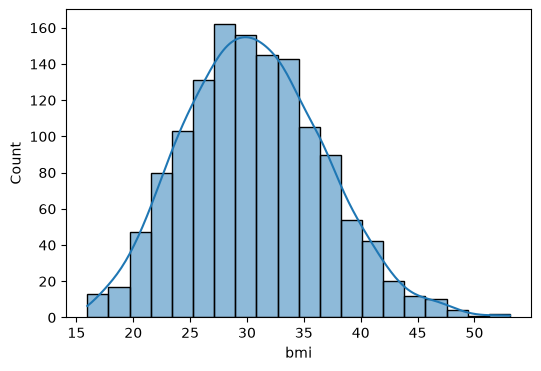

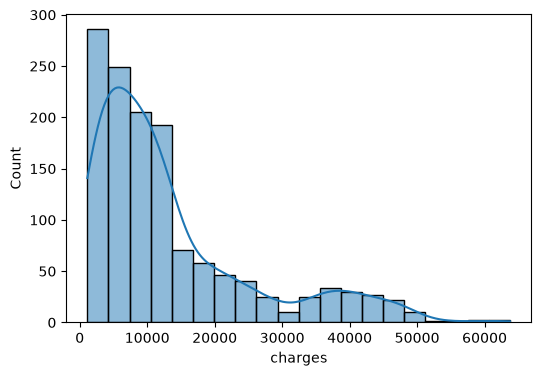

In [25]:
# Visualising the data

numeric_columns = ['age', 'bmi', 'charges']
for col in numeric_columns:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde = True, bins = 20)
    
# kde - Kernel Density Estimate - adds a smooth curve showing the estimate distribution of the data

<Axes: xlabel='children', ylabel='count'>

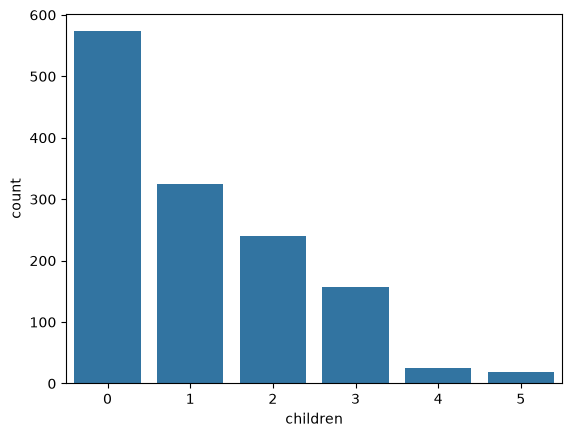

In [26]:
# for children column 

sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

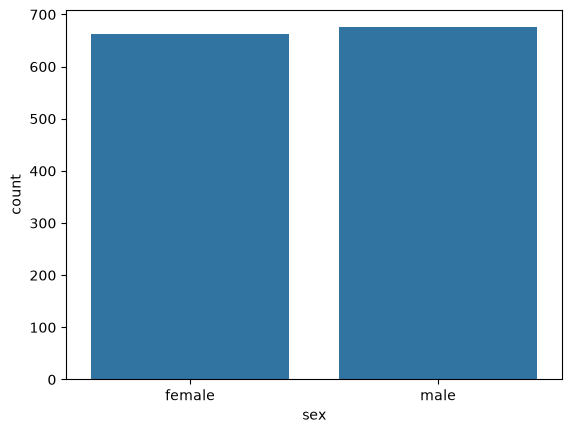

In [27]:
# for 'sex' column 

sns.countplot(x = df['sex'])

<Axes: xlabel='count', ylabel='smoker'>

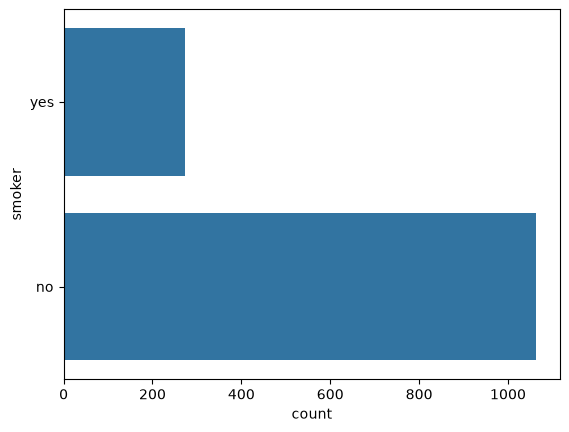

In [28]:
# countplot for smoker column 

sns.countplot(df['smoker'])

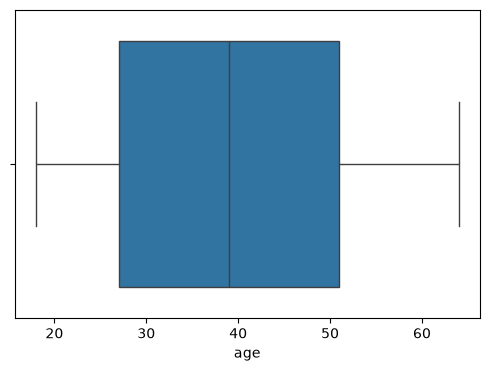

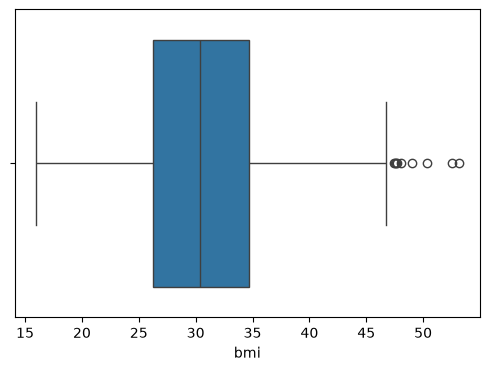

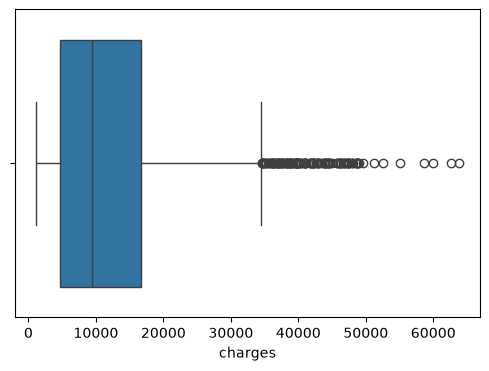

In [29]:
# visualising numeric columns through boxplots

for col in numeric_columns:
    plt.figure(figsize = (6, 4))
    sns.boxplot(x = df[col])

<Axes: >

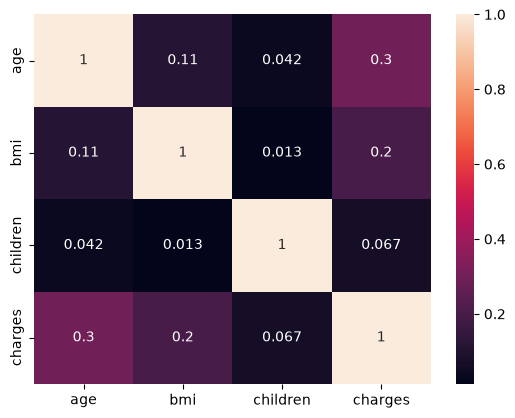

In [30]:
# visualising correlation using heatmap

sns.heatmap(df.corr(numeric_only = True), annot = True)

In [31]:
# splitting the dataset into training data and testing data

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

train_df.to_csv("../data/raw/train.csv", index=False)
test_df.to_csv("../data/raw/test.csv", index=False)